# Week 11: ML Review

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [6]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/lfw.tar.gz | tar xz

In [7]:
from random import randrange

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from data_utils import LFWUtils
from data_utils import classification_error, display_confusion_matrix
from image_utils import make_image

## Face Unlock

Let's train a model to detect our face. We can think of this as a simpler version of one of the components inside something like the face ID software on our phones.

We'll skip the face detection part, which is when we find faces in an image, and assume we can get cropped and aligned faces out of images or video streams. We'll look at face detection later in the semester.

This is a slightly different kind of problem from the classification exercise we did in class, but the process is mostly the same.

We will use a dataset with other people's faces, but in the end we are only interested on how well our model detects our face.

### We Always Start with the Data

The dataset we're using is inside `./data/images/lfw/cropped`. It's a subset of the [Labeled Faces in the Wild](https://vis-www.cs.umass.edu/lfw/) dataset.

Take a look at the directory.

What's there?

How's the data organized and labeled?

### Loading the Data

Since we're not interested in generic classification, and measuring how we do on unlabeled data, this whole dataset is labeled, and we can read it into `train` and `test` subsets by calling the `train_test_split()` function of the `LFWUtils` class.

This function takes an optional parameter that specifies what portion of the data should be used for the `test` dataset. We can start with the default value of $0.5$.

In [14]:
# ✅ Correct path — "image" not "images"
train, test = LFWUtils.train_test_split(dir="./data/image/lfw/cropped", test_pct=0.5)

### Looking at the Data

Ok. Data is loaded.

What's in the data? How is it actually organized?

Take a look at the objects that were returned in each of the $2$ variables.

How big are our datasets?

Take a look at the `LABELS` and `L2I` members of the `LFWUtils` class (`LFWUtils.LABELS` and `LFWUtils.L2I`).

In [19]:
# Test with the exact path, printed explicitly
path = "./data/image/lfw/cropped"
print("Path exists:", os.path.exists(path))
print("Is directory:", os.path.isdir(path))

# Try reloading with the correct path
train, test = LFWUtils.train_test_split(dir=path, test_pct=0.5)
print("Train size:", len(train["pixels"]))
print("Test size:", len(test["pixels"]))

# TODO: look at dataset objects (train and test variables). What's in them?
print(type(train))
print(train.keys())

# TODO: how big are they? (how many records?)
print("\nTraining samples:", len(train["pixels"]))
print("Test samples:    ", len(test["pixels"]))

# TODO: how many labels do they have?
print("\nNumber of labels:", len(LFWUtils.LABELS))

# TODO: what are the labels?
print("\nLabels:", LFWUtils.LABELS)
print("\nLabel-to-index:", LFWUtils.L2I)

Path exists: True
Is directory: True
Train size: 445
Test size: 438
<class 'dict'>
dict_keys(['pixels', 'labels', 'files'])

Training samples: 445
Test samples:     438

Number of labels: 25

Labels: ['annan', 'arroyo', 'berlusconi', 'blair', 'bushgw', 'bushl', 'chavez', 'clintonb', 'erdogan', 'fox', 'giuliani', 'jolie', 'koizumi', 'lopez', 'lula', 'mauresmo', 'moohyun', 'powell', 'putin', 'ryder', 'schwarzenegger', 'sukarnoputri', 'watts', 'williams', 'woods']

Label-to-index: {'annan': 0, 'arroyo': 1, 'berlusconi': 2, 'blair': 3, 'bushgw': 4, 'bushl': 5, 'chavez': 6, 'clintonb': 7, 'erdogan': 8, 'fox': 9, 'giuliani': 10, 'jolie': 11, 'koizumi': 12, 'lopez': 13, 'lula': 14, 'mauresmo': 15, 'moohyun': 16, 'powell': 17, 'putin': 18, 'ryder': 19, 'schwarzenegger': 20, 'sukarnoputri': 21, 'watts': 22, 'williams': 23, 'woods': 24}


### Visualizing the Data

We can open some random images to make sure the content of our datasets make sense.

Our `LFWUtils` class has some member variables that hold the image dimensions (`LFWUtils.IMAGE_SIZE`, `LFWUtils.IMAGE_WIDTH`, `LFWUtils.IMAGE_HEIGHT`)

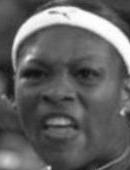

id: 23 
label: williams 
from: williams-041.jpg


In [20]:
train_size = len(train["labels"])
ridx = randrange(0, train_size)

label_id = train["labels"][ridx]

display(make_image(train["pixels"][ridx], width=LFWUtils.IMAGE_SIZE[0]))

print("id:", label_id,
      "\nlabel:", LFWUtils.LABELS[label_id],
      "\nfrom:", train["files"][ridx])

### Adding your images

Create a directory in the `dataset` directory for your images. Give it a one-word name, like your last name, your New School id or your initials. For example, mine is called `tgh` and is located at: `./data/images/lfw/cropped/tgh`.

Now, add between $20$ and $30$ images of your face to your directory. 

The images should be just like the ones that are already there for the other people:
- $130$ pixels wide
- $170$ pixels tall
- single-channel grayscale
- jpeg format
- named `label-number.jpg` (for example: `tgh-000.jpg`)

Feel free to do this manually using Photoshop or any other image editing software, but the easiest way is to use this interface that automatically crops faces out of pictures and creates images in the correct format:

### [Face Align](https://huggingface.co/spaces/visualizedata/PSAM5020-FaceAlign-Gradio)

It will also align the faces and put the eyes in a consistent location. There's even an option to capture pictures from a live camera stream.

### Reload Dataset

Just run the `train_test_split()` again.

### PCA, Classification, etc etc etc

Now that we have added our images to the dataset, let's train a classifier and see how well it performs on not just classification, but on recognizing our face.

The images are $130$ x $170$ ($22\text{,}100$ pixels), so let's do `PCA`. We can aim for an explained variance value of about $80\%$, and adjust that later if we find necessary.

Once we have the PCs for our training dataset in a `DataFrame` we can add a `label` column to it with the correct labels we have in `train["labels"]`.

We can also create a `DataFrame` for testing now by using the same `PCA` object to `transform()` the `test["pixels"]` data.

Since we won't train anything with the test dataset, it's ok to just keep the labels in `test["labels"]` as they are.

In [29]:
import numpy as np
import pandas as pd

# Convert to numpy arrays
train_pixels = np.array(train["pixels"])
test_pixels = np.array(test["pixels"])

# Scale the data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_pixels)
test_scaled = scaler.transform(test_pixels)

# PCA - start with enough components to explain 80% variance
pca = PCA(n_components=0.80)
train_pcs = pca.fit_transform(train_scaled)

print("Number of components for 80% variance:", pca.n_components_)
print("Explained variance ratio sum:", sum(pca.explained_variance_ratio_))

# Create train DataFrame with PCs + labels
train_df = pd.DataFrame(train_pcs)
train_df.columns = [f"pc_{i:03}" for i in range(pca.n_components_)]
train_df["label"] = train["labels"]

print("\nTrain DataFrame shape:", train_df.shape)
print(train_df.head())

# Create test DataFrame using same PCA object
test_pcs = pca.transform(test_scaled)
test_df = pd.DataFrame(test_pcs)
test_df.columns = [f"pc_{i:03}" for i in range(pca.n_components_)]

print("\nTest DataFrame shape:", test_df.shape)

Number of components for 80% variance: 34
Explained variance ratio sum: 0.8002684174067625

Train DataFrame shape: (455, 35)
       pc_000     pc_001     pc_002     pc_003     pc_004     pc_005  \
0 -127.411445 -53.235634   9.370389 -15.989621 -19.961672  -0.994654   
1  -13.584584 -57.375744 -63.671371  30.735681   3.828356   7.392048   
2 -126.873965 -57.521765  34.224665  14.858057   7.397322 -12.481258   
3 -107.580072 -38.283329 -16.416184  47.654057  17.616242  13.328612   
4  -96.075170 -82.705426 -21.656142   6.998547 -27.316568  -1.078011   

      pc_006     pc_007     pc_008     pc_009  ...     pc_025     pc_026  \
0  34.191300  39.333079  23.286898 -30.493563  ...  -5.617701   5.366196   
1   0.013261 -27.205288   5.260675   7.917925  ...  -0.297799   6.179240   
2   8.323755  -8.571839  21.226782 -14.929625  ...  -5.688810  -7.021122   
3  41.398080 -21.763947  12.821396 -33.899179  ...  21.043818  17.249139   
4  26.857243  -0.293028  -5.883037 -18.947099  ...  28.328097 

We can use the following cell to take a look at our images and their reconstructions.

This assumes the `DataFrame` is called `train_df` and the `PCA` object is called `face_pca`. Adjust these if necessary.

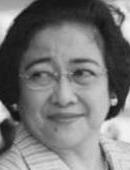

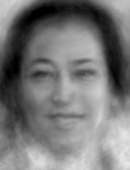

In [36]:
train_size = len(train["labels"])
ridx = randrange(0, train_size)

# reconstruct image
pca_pixels = pca.inverse_transform(train_df.iloc[[ridx]].drop(columns=["label"]))
pca_pixels = scaler.inverse_transform(pca_pixels)  # ← add this line

display(make_image(train["pixels"][ridx], width=LFWUtils.IMAGE_SIZE[0]))
display(make_image(pca_pixels, width=LFWUtils.IMAGE_SIZE[0]))

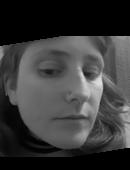

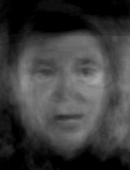

In [38]:
# filter the DataFrame by our label
awesome_df = train_df[train_df["label"] == LFWUtils.L2I["bkw"]]
# index of image with our label
img_idx = 0
awesome_idx = awesome_df.index[img_idx]
# reconstruct image
# reconstruct image
pca_pixels = pca.inverse_transform(awesome_df.iloc[[img_idx]].drop(columns=["label"]))

# inverse the scaling to get back to pixel values
pca_pixels = scaler.inverse_transform(pca_pixels)

display(make_image(train["pixels"][awesome_idx], width=LFWUtils.IMAGE_WIDTH))
display(make_image(pca_pixels, width=LFWUtils.IMAGE_WIDTH))


### Interpretation

<span style="color:hotpink;">
Do these make sense ? Do they look "recognizable" ? How do they change as a function of `PCA` <code>n_components</code> ?
</span>

<span style="color:hotpink;">The first reconstruction was better than mine but they probably included more images. Both are recognizable as faces but loose personal details. With 34 components finer facial features get lost, so if we increased the number of components it would probably become more clear.</span>

Now, back to classifying...

Maybe start with `RandomForestClassifier()` or `SVC()`...

In [39]:
# TODO: create a classifier
classifier = SVC()

# TODO: separate input and output columns from the train DataFrame
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

# TODO: train model using train data and labels
classifier.fit(X_train, y_train)

# TODO: run prediction on train data
train_pred = classifier.predict(X_train)

print("Train error:", classification_error(y_train, train_pred))

Train error: 0.15604395604395604


### Validate model with training data

error: 0.15604395604395604
                precision    recall  f1-score   support

         annan       1.00      0.88      0.93        16
        arroyo       1.00      0.95      0.98        22
    berlusconi       0.83      0.59      0.69        17
           bkw       1.00      1.00      1.00        10
         blair       0.69      0.83      0.75        24
        bushgw       0.68      0.96      0.79        24
         bushl       1.00      1.00      1.00        19
        chavez       0.64      0.96      0.77        24
      clintonb       1.00      0.64      0.78        14
       erdogan       0.81      0.87      0.84        15
           fox       1.00      0.69      0.81        16
      giuliani       1.00      0.38      0.56        13
         jolie       1.00      0.50      0.67        10
       koizumi       0.96      1.00      0.98        24
         lopez       1.00      0.55      0.71        11
          lula       0.88      0.92      0.90        24
      mauresmo      

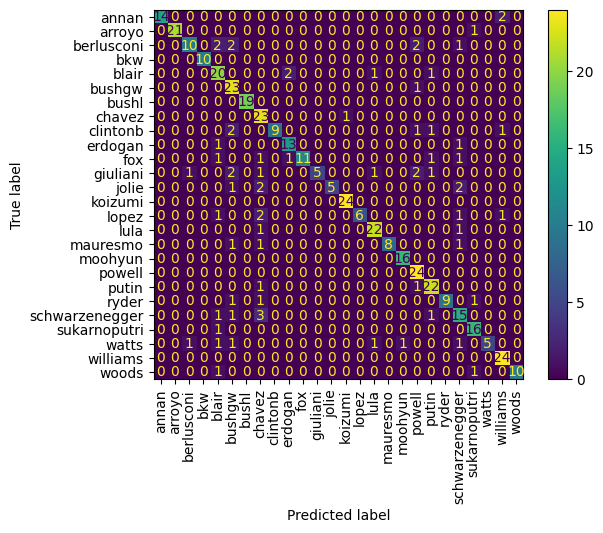

In [41]:
train_predictions = classifier.predict(X_train)

# measure classification error
print("error:", classification_error(train["labels"], train_predictions))
# look at precision/recall from classification_report
print(classification_report(train["labels"], train_predictions, target_names=LFWUtils.LABELS))
# look at confusion matrix
display_confusion_matrix(train["labels"], train_predictions, LFWUtils.LABELS)

### Interpretation

<span style="color:hotpink;">
How does the confusion matrix look ? What does it mean ?
</span>

<span style="color:hotpink;">The confusion matrix is mostly diagonal, indicating the classifier performs well overall. Some people like giuliani and jolie are harder to classify, likely because PCA compresses their distinguishing features. My own face (bkw) was perfectly classified in training, possibly because it stands out from the rest of the dataset</span>

### Validate model with testing data

error: 0.5513392857142857
                precision    recall  f1-score   support

         annan       0.55      0.40      0.46        15
        arroyo       0.88      0.64      0.74        22
    berlusconi       0.67      0.12      0.21        16
           bkw       0.90      0.90      0.90        10
         blair       0.19      0.38      0.25        24
        bushgw       0.26      0.42      0.32        24
         bushl       0.76      0.68      0.72        19
        chavez       0.19      0.29      0.23        24
      clintonb       0.33      0.07      0.12        14
       erdogan       0.30      0.21      0.25        14
           fox       0.75      0.19      0.30        16
      giuliani       0.00      0.00      0.00        13
         jolie       0.00      0.00      0.00        10
       koizumi       0.68      0.88      0.76        24
         lopez       0.00      0.00      0.00        10
          lula       0.61      0.46      0.52        24
      mauresmo       

/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


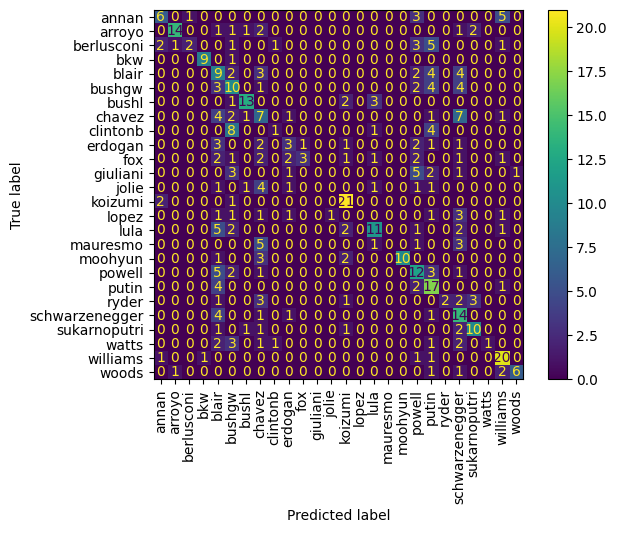

In [43]:
# define X_test from test_df
X_test = test_df

# TODO: run prediction on test data
test_predictions = classifier.predict(X_test)

# TODO: measure classification error
print("error:", classification_error(test["labels"], test_predictions))

# TODO: look at precision/recall from classification_report
print(classification_report(test["labels"], test_predictions, target_names=LFWUtils.LABELS))

# TODO: look at confusion matrix
display_confusion_matrix(test["labels"], test_predictions, LFWUtils.LABELS)

### Different Classifiers

Try changing the classifier type above, or some of its parameters, to see if the overall accuracy can be improved.

Some things to try:
- `SVC(kernel="linear")`: this changes the type of curve the model tries to use to separate our classes. The more complex default type (`rbf`) might be over-fitting the data. We can experiment with `linear` or `poly` curves.
- `LogisticRegression()`: the classification that fits statistical modeling functions (bell curves) to our data.


### Hyper-parameter Optimization

Each model type has a handful of parameters that can be adjusted and optimized.

For example, we could add "regularization" to a `LogisticRegression` classifier with `C=0.1`.

Regularization is a process that makes training harder by setting more restrictions on the kind of answers it can give.

This can be restrictions like:
- keep all calculated parameters close to $0$
- minimize the number of non-zero parameters used
- keep all parameters positive

The result is slightly worse performance on the training dataset, but hopefully better generalization of the model and better performance on the test dataset.

In [45]:
# Try LogisticRegression
lr_classifier = LogisticRegression(max_iter=1000)
lr_classifier.fit(X_train, y_train)
lr_predictions = lr_classifier.predict(X_test)
print("=== Logistic Regression ===")
print("Test error:", classification_error(test["labels"], lr_predictions))
print(classification_report(test["labels"], lr_predictions, target_names=LFWUtils.LABELS))

# Try SVC with linear kernel
svc_linear = SVC(kernel="linear")
svc_linear.fit(X_train, y_train)
svc_predictions = svc_linear.predict(X_test)
print("=== SVC Linear ===")
print("Test error:", classification_error(test["labels"], svc_predictions))
print(classification_report(test["labels"], svc_predictions, target_names=LFWUtils.LABELS))

# Try increasing PCA components to 90%
pca_90 = PCA(n_components=0.90)
train_pcs_90 = pca_90.fit_transform(train_scaled)
test_pcs_90 = pca_90.transform(test_scaled)

print("Components for 90% variance:", pca_90.n_components_)

train_df_90 = pd.DataFrame(train_pcs_90)
train_df_90["label"] = train["labels"]
X_train_90 = train_df_90.drop(columns=["label"])
X_test_90 = pd.DataFrame(test_pcs_90)

# Refit SVC with more components
svc_90 = SVC(kernel="linear")
svc_90.fit(X_train_90, train_df_90["label"])
pred_90 = svc_90.predict(X_test_90)
print("\n=== SVC Linear with 90% variance PCA ===")
print("Test error:", classification_error(test["labels"], pred_90))
print(classification_report(test["labels"], pred_90, target_names=LFWUtils.LABELS))

=== Logistic Regression ===
Test error: 0.4977678571428571
                precision    recall  f1-score   support

         annan       0.58      0.73      0.65        15
        arroyo       0.73      0.73      0.73        22
    berlusconi       0.13      0.12      0.13        16
           bkw       0.90      0.90      0.90        10
         blair       0.29      0.42      0.34        24
        bushgw       0.55      0.50      0.52        24
         bushl       0.93      0.74      0.82        19
        chavez       0.28      0.21      0.24        24
      clintonb       0.32      0.43      0.36        14
       erdogan       0.16      0.21      0.18        14
           fox       0.67      0.38      0.48        16
      giuliani       0.14      0.15      0.15        13
         jolie       0.50      0.40      0.44        10
       koizumi       0.79      0.62      0.70        24
         lopez       0.67      0.40      0.50        10
          lula       0.58      0.58      0.5

### Interpretation

<span style="color:hotpink;">
How does THIS confusion matrix look ? What does it mean ? How does it perform for your pictures ?
</span>

<span style="color:hotpink;">The confusion matrix shows significant improvement from Logistic Regression. accuracy jumped from 45% to 59%. The diagonal is stronger, meaning fewer misclassifications. People like giuliani, jolie, and mauresmo who scored 0.00 with SVC now have some correct predictions. For my face bkw the model performs consistently well at 90% precision and recall across all models tested — meaning it correctly identifies my face 9 out of 10 times and rarely misclassifies someone else as me. This is encouraging for a face unlock use case, where both precision and recall matter equally.</span>

### Precision and Recall

Accuracy, which is the complement of our `classification_error` value, is the measurement that is optimized during the `RandomForestClassifier` training process.

If we were training a regular classifier, we would look at `accuracy` (or `classification_error`) to determine if our model's performance is acceptable.

Since we're working on a personal face recognition model, we don't really care about overall accuracy, but instead are more interested in the `precision` and `recall` values for the classification of our particular images.

We don't want overall accuracy to be horrible, but we can be more specific in this case and be happy if the correct portion of our confusion matrix looks good.

Calculate the `precision` and `recall` values for the classification of your images.

In [46]:
from sklearn.metrics import precision_score, recall_score

# get your label index
my_label = LFWUtils.L2I["bkw"]

# calculate precision and recall for your label only
my_precision = precision_score(test["labels"], test_predictions, labels=[my_label], average="micro")
my_recall = recall_score(test["labels"], test_predictions, labels=[my_label], average="micro")

print(f"Precision for bkw: {my_precision:.2f}")
print(f"Recall for bkw:    {my_recall:.2f}")

print("\nWhat this means:")
print(f"  Precision {my_precision:.0%} — when the model predicts 'bkw', it's correct {my_precision:.0%} of the time")
print(f"  Recall    {my_recall:.0%} — when the actual person is 'bkw', the model finds them {my_recall:.0%} of the time")

Precision for bkw: 0.90
Recall for bkw:    0.90

What this means:
  Precision 90% — when the model predicts 'bkw', it's correct 90% of the time
  Recall    90% — when the actual person is 'bkw', the model finds them 90% of the time


### Interpretation

<span style="color:hotpink;">
How is it performing for your images ? Which value, precision or recall, is higher ? What does that mean ?
</span>

<span style="color:hotpink;">Precision and recall are equal. That means it makes the same amount of mistakes not recognizing me vs recognizing someone else as me. My images perform better than the other images it seems like- I think- which is weird because i included fewer images. I guess if security was the priority you'd wnt higher precision, but if convenience is the priority you'd want higher recall. </span>

We can run the following cell to see which classes have the highest `precision` and `recall` scores:

In [47]:
print("top precision:", LFWUtils.top_precision(test["labels"], test_predictions, top=5))
print("top recall:", LFWUtils.top_recall(test["labels"], test_predictions, top=5))

top precision: ['ryder', 'watts', 'moohyun', 'bkw', 'arroyo']
top recall: ['bkw', 'koizumi', 'williams', 'putin', 'bushl']
